In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 2000)        # use very wide width
pd.set_option("display.max_columns", None)  # show all columns
pd.set_option("display.max_colwidth", None) # do not truncate text
pd.set_option("display.expand_frame_repr", False)  # no wrapping

In [55]:

df = pd.read_parquet("data/processed/cfr_savings_processed.parquet")
print(f"Rows: {len(df)} | Columns: {len(df.columns)}")
print(df.columns.tolist())

Rows: 13194 | Columns: 117
['case_number', 'case_priority', 'case_type', 'subject', 'creation_date', 'disposition_date', 'teco_date', 'market', 'country', 'ib_service_team', 'remote_remarks', 'field_remarks', 'remote_remarks_en', 'field_remarks_en', 'equipment', 'system_code', 'parts_consumed_list', 'remote_hours', 'travel_hours', 'onsite_hours', 'offsite_hours', 'total_hours', 'ttsu_days', 'ttsu_bucket', 'diagnostic_text', 'diagnostic_date', 'follow_up_text', 'follow_up_date', 'problem_description_text', 'problem_description_date', 'resolution_text', 'resolution_date', 'internal_comments_text', 'internal_comments_date', 'internal_remarks_text', 'internal_remarks_date', 'external_remarks_text', 'external_remarks_date', 'parent_diagnostic_text', 'parent_diagnostic_date', 'parent_follow_up_text', 'parent_follow_up_date', 'parent_problem_description_text', 'parent_problem_description_date', 'parent_resolution_text', 'parent_resolution_date', 'parent_internal_comments_text', 'parent_intern

In [56]:
country_count = (
    df.groupby('country')
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

C:\Users\320305732\AppData\Local\Temp\ipykernel_16584\879383729.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", min(TOP_N, 20))


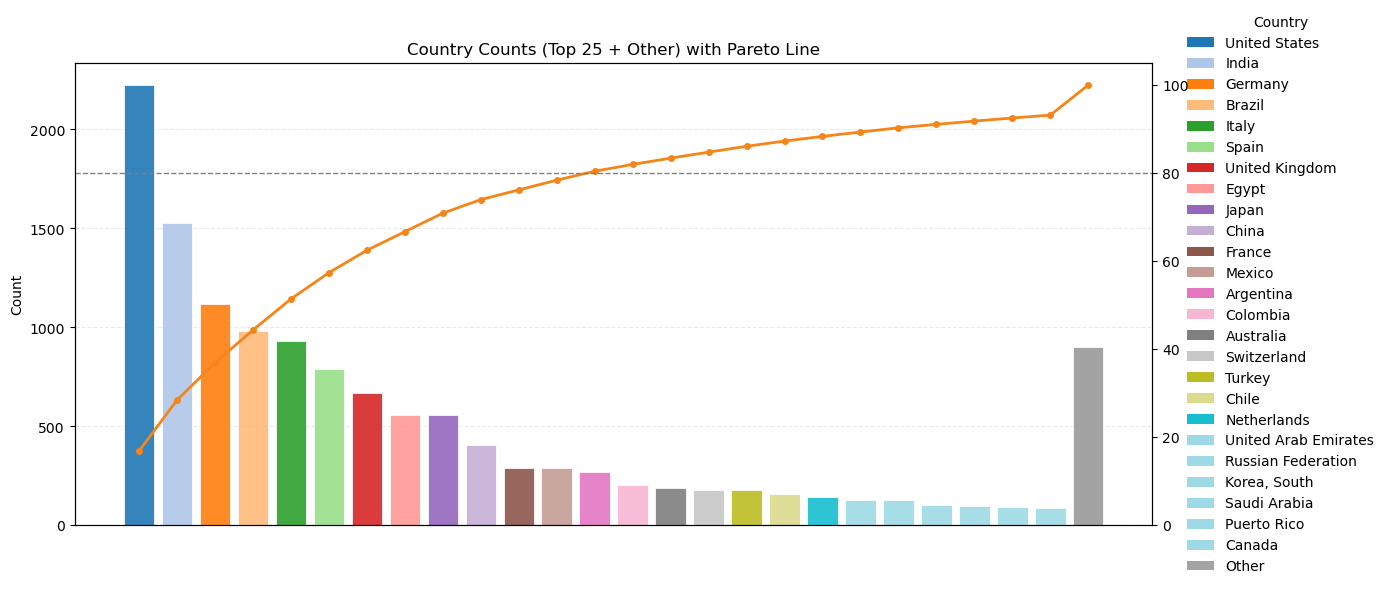

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

TOP_N = 25

# --- Build Top N + Other ---
cc = country_count.copy()
cc["country"] = cc["country"].astype(str)
cc["count"] = cc["count"].astype(float)

top = cc.head(TOP_N).copy()
other = cc["count"].iloc[TOP_N:].sum()

if other > 0:
    plot_df = pd.concat(
        [top, pd.DataFrame([{"country": "Other", "count": other}])],
        ignore_index=True
    )
else:
    plot_df = top.copy()

plot_df["cum_pct"] = plot_df["count"].cumsum() / plot_df["count"].sum() * 100

# --- Colors (Top 20 + gray for Other) ---
cmap = plt.cm.get_cmap("tab20", min(TOP_N, 20))
colors = [cmap(i) for i in range(len(plot_df))]
if plot_df["country"].iloc[-1] == "Other":
    colors[-1] = (0.6, 0.6, 0.6, 0.9)

# --- Plot ---
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x, plot_df["count"], color=colors, alpha=0.9, edgecolor="white", linewidth=0.6)
ax.set_ylabel("Count")
ax.set_title(f"Country Counts (Top {TOP_N} + Other) with Pareto Line")
ax.yaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Remove x-axis tick labels (legend will be used instead)
ax.set_xticks([])
ax.set_xlabel("")  # no label under bars

# Pareto line (secondary axis)
ax2 = ax.twinx()
ax2.plot(x, plot_df["cum_pct"], color="#F58518", marker="o", linewidth=2, markersize=4)
#ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

# Legend on the right (one entry per bar)
handles = [Patch(facecolor=colors[i], edgecolor="none") for i in range(len(plot_df))]
labels = plot_df["country"].tolist()

ax.legend(
    handles, labels,
    title="Country",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

In [48]:
key_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

for col in key_cols:
    filled = df[col].notna().sum()
    pct = round(filled / len(df) * 100, 1)
    print(f"{col}: {filled} ({pct}%)")

extracted_problem_description_field: 7056 (53.5%)
extracted_error_field: 12 (0.1%)
extracted_malfunction_area_field: 2972 (22.5%)
extracted_troubleshooting_field: 27 (0.2%)
extracted_repair_action_field: 6615 (50.1%)
extracted_problem_description_remote: 11948 (90.6%)
extracted_error_remote: 4004 (30.3%)
extracted_malfunction_area_remote: 5738 (43.5%)
extracted_troubleshooting_remote: 1368 (10.4%)
extracted_repair_action_remote: 10117 (76.7%)


In [63]:
field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

# Denominators
field_den = df["field_remarks"].notna().sum()
remote_den = df["remote_remarks"].notna().sum()

# Field-based extraction %
for col in field_cols:
    extracted = df.loc[df["field_remarks"].notna(), col].notna().sum()
    pct = round(extracted / field_den * 100, 1) if field_den else 0.0
    print(f"{col}: {extracted} / {field_den} ({pct}%)")

# Remote-based extraction %
for col in remote_cols:
    extracted = df.loc[df["remote_remarks"].notna(), col].notna().sum()
    pct = round(extracted / remote_den * 100, 1) if remote_den else 0.0
    print(f"{col}: {extracted} / {remote_den} ({pct}%)")

extracted_problem_description_field: 7010 / 7598 (92.3%)
extracted_error_field: 12 / 7598 (0.2%)
extracted_malfunction_area_field: 2954 / 7598 (38.9%)
extracted_troubleshooting_field: 27 / 7598 (0.4%)
extracted_repair_action_field: 6572 / 7598 (86.5%)
extracted_problem_description_remote: 11905 / 12289 (96.9%)
extracted_error_remote: 3994 / 12289 (32.5%)
extracted_malfunction_area_remote: 5722 / 12289 (46.6%)
extracted_troubleshooting_remote: 1366 / 12289 (11.1%)
extracted_repair_action_remote: 10087 / 12289 (82.1%)


In [64]:
field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

rows = []

# Denominators
field_den = df["field_remarks"].notna().sum()
remote_den = df["remote_remarks"].notna().sum()

# Field-based metrics
for col in field_cols:
    extracted = df.loc[df["field_remarks"].notna(), col].notna().sum()
    pct = round(extracted / field_den * 100, 1) if field_den else 0.0

    rows.append({
        "scope": "field",
        "variable": col,
        "extracted_count": extracted,
        "eligible_count": field_den,
        "extraction_pct": pct,
    })

# Remote-based metrics
for col in remote_cols:
    extracted = df.loc[df["remote_remarks"].notna(), col].notna().sum()
    pct = round(extracted / remote_den * 100, 1) if remote_den else 0.0

    rows.append({
        "scope": "remote",
        "variable": col,
        "extracted_count": extracted,
        "eligible_count": remote_den,
        "extraction_pct": pct,
    })

extraction_summary = pd.DataFrame(rows)
extraction_summary

,scope,variable,extracted_count,eligible_count,extraction_pct
0,field,extracted_problem_description_field,7010,7598,92.3
1,field,extracted_error_field,12,7598,0.2
2,field,extracted_malfunction_area_field,2954,7598,38.9
3,field,extracted_troubleshooting_field,27,7598,0.4
4,field,extracted_repair_action_field,6572,7598,86.5
5,remote,extracted_problem_description_remote,11905,12289,96.9
6,remote,extracted_error_remote,3994,12289,32.5
7,remote,extracted_malfunction_area_remote,5722,12289,46.6
8,remote,extracted_troubleshooting_remote,1366,12289,11.1
9,remote,extracted_repair_action_remote,10087,12289,82.1


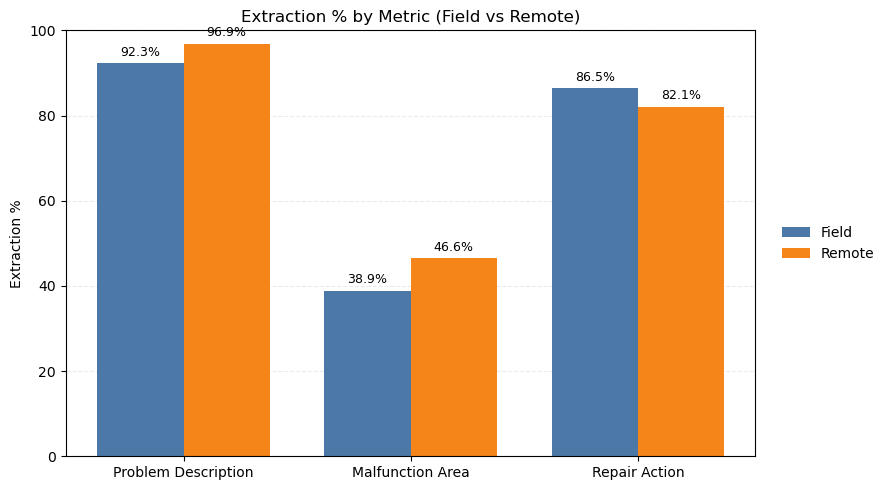

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics you want to compare
metrics = [
    "problem_description",
    "malfunction_area",
    "repair_action",
]

field_cols  = [f"extracted_{m}_field"  for m in metrics]
remote_cols = [f"extracted_{m}_remote" for m in metrics]

# Denominators (eligible rows)
field_mask  = df["field_remarks"].notna()
remote_mask = df["remote_remarks"].notna()
field_den   = field_mask.sum()
remote_den  = remote_mask.sum()

# Percentages
field_pct = [(df.loc[field_mask,  c].notna().sum() / field_den  * 100) if field_den  else 0 for c in field_cols]
remote_pct = [(df.loc[remote_mask, c].notna().sum() / remote_den * 100) if remote_den else 0 for c in remote_cols]

# Plot (grouped bars)
x = np.arange(len(metrics))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - w/2, field_pct,  width=w, color="#4C78A8", label="Field")
ax.bar(x + w/2, remote_pct, width=w, color="#F58518", label="Remote")

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics])
ax.set_ylabel("Extraction %")
ax.set_ylim(0, 100)
ax.set_title("Extraction % by Metric (Field vs Remote)")
ax.yaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Value labels on top of bars
for i, v in enumerate(field_pct):
    ax.text(x[i] - w/2, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(remote_pct):
    ax.text(x[i] + w/2, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [36]:
sample = df[df["extracted_problem_description_field"].notna()].iloc[0]
print("Problem:", sample["extracted_problem_description_field"])
print("Repair:", sample["extracted_repair_action_field"])
print("Malfunction:", sample["extracted_malfunction_area_field"])

Problem: Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the breakers,  No PRS connection, Remote password is not set,
Repair: nan
Malfunction: nan


In [37]:
mask = df["extracted_problem_description_field"].isna()
print(df[mask]["diagnostic_text"].notna().sum())

204


In [38]:
mask = (
    df["extracted_problem_description_field"].isna() &
    df["diagnostic_text"].notna()
)
print(df[mask].iloc[0]["diagnostic_text"][:300])

In [39]:
mask = (
    df["extracted_problem_description_field"].isna() &
    df["diagnostic_text"].notna()
)

# Check actual values
print(repr(df[mask].iloc[0]["diagnostic_text"]))
print(type(df[mask].iloc[0]["diagnostic_text"]))

''
<class 'str'>


Check failed extraction, orginal nan vs problem description None

In [40]:
mask = df["extracted_problem_description_remote"].isna()
print(f"Missing remote problem description: {mask.sum()}")
print(f"Of those, missing remote_remarks entirely: {df[mask]['remote_remarks'].isna().sum()}")

Missing remote problem description: 1912
Of those, missing remote_remarks entirely: 863


In [41]:
# rows that have remote_remarks but failed extraction
mask_failed = (
    df["extracted_problem_description_remote"].isna() & 
    df["remote_remarks"].notna()
)

# check country distribution of failures
print(df[mask_failed]["country"].value_counts().head(10))

# look at a raw example
print(df[mask_failed].iloc[0]["remote_remarks_en"][:500])

country
United States         211
United Kingdom        133
Russian Federation    121
Egypt                  51
Brazil                 49
Spain                  43
Italy                  39
Netherlands            36
China                  31
Germany                30
Name: count, dtype: int64[pyarrow]
*** T2 Activities [2025-06-16 08:06:50]
Troubleshooting Action: Site audit of the system is required, 

To carry out an FRT specialist or a 4K specialist is required, 

This tool will be needed to audit the system after a quench: 

1) FLUKE-435 Power Quality Analyzer,435/001 2654779 4000435001 
2) Resistance meter IS-20/1, which includes clamps 20/1 - 2136, 20/2 - 0744 
3) TC025 - Earth bonding tester â 452298038072[3] 
or TC378 452298038073 EARTH BONDING TESTER Gossen Secutest SIII+(+IEC Leak


In [42]:
# Sample 5 rows per country from top 10 countries
top_countries = df["country"].value_counts().head(10).index

for country in top_countries:
    sample = df[df["country"] == country]["extracted_problem_description_remote"].dropna().head(5)
    print(f"\n=== {country} ===")
    for text in sample:
        print(f"  → {text[:150]}")


=== United States ===
  → Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the brea
  → The chiller is down and is not powering back on- Ongoing issue
  → Biomed had question on vertical actuator on the table that is down,
  → The unit will not run after power surge
  → Both UPS's show battery low and system will not come up,

=== India ===
  → Reconstructor aborted after internal error
  → Workstation system is not switching On
  → Compressor Helium return gas line  leakage
  → 497732	2025-04-30 11:56:20,950	Warning	Examcards                      	12368	        	UGTXT: key CONF: Device not configured, Please contact Philips C
  → Table up and down movement not happening

=== Germany ===
  → mit Te Sven Lischer telefoniert,
Die StÃ¶rung wird bestÃ¤tigt,
  → Das gemeldete Problem wird bestÃ¤tigt
  → Mr. Frackiewicz has already shut down the system three times via the circuit breakers, He was as


=== Brazil ===
  → Problem description by engineer: 
The Sense Body coil connector pin was severely damaged and, insisting on its use damaged the two PICU QCH Kit connec
  → Problem description by engineer: 
Customer got in touch reporting equipment not initializing exams, with messages saying "Spectrometer initializing",
  → Alerta MR,M2M,MagnetSealed_Alert V1,5
  → Intercomunicador apresenta falha permanente,
  → Problem description by engineer: 
The reconstructor initialization fails,

=== Italy ===
  → Magnetic field turned off due to problems with the customer's chiller [SEP] Magnetic field turned off due to problems with the customer's chiller
  → Contacted the doctor on duty who informed me that the workstation does not turn on and there is a flashing orange LED,
  → The remote connection shows system completely shut down for 5 hours on the morning of April 20th, resulting in the magnetic field shutting down,
All c
  → Durante esame si Ã¨ bloccata dopo riavvio Âscan resource n

In [43]:
case = df[df["case_number"] == 125721564].iloc[0]

# Raw input
print("=== RAW REMOTE REMARKS ===")
print(case["remote_remarks_en"])

print("\n=== LAYER 1 — Intermediate columns ===")
print("t2_activities_text_remote:", repr(case["t2_activities_text_remote"]))
print("problem_description_text_remote:", repr(case["problem_description_text_remote"]))
print("resolution_text_remote:", repr(case["resolution_text_remote"]))

print("\n=== LAYER 2 — Extracted columns ===")
print("extracted_problem_description_remote:", repr(case["extracted_problem_description_remote"]))
print("extracted_troubleshooting_remote:", repr(case["extracted_troubleshooting_remote"]))
print("extracted_repair_action_remote:", repr(case["extracted_repair_action_remote"]))

=== RAW REMOTE REMARKS ===
*** T2 Activities [2025-06-30 00:20:52]
Problem Description: Fault type:
Magnet
Detailed description of customer problem or fault phenomenon:
Equipment quench
Whether it is a fault of the equipment itself:
Yes
Troubleshooting Action: Key fault codes or phenomena:
NA
Remote diagnostics and test results:
The customer reported equipment failure for repair.
PRS TR status:
All Access
Repair Action: T2 Recommended on-site repair steps:
Arrive at the scene as soon as possible, replace the blasting film, and de-ice the excitation.
T2 recommended spare parts 12NC and name:
NA
Notes on customer requirements:
None
Case Level
H

=== LAYER 1 — Intermediate columns ===
t2_activities_text_remote: 'Problem Description: Fault type:\nMagnet\nDetailed description of customer problem or fault phenomenon:\nEquipment quench\nWhether it is a fault of the equipment itself:\nYes\nTroubleshooting Action: Key fault codes or phenomena:\nNA\nRemote diagnostics and test results:\nThe cust

In [45]:
import pandas as pd
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

# --- Config ---
PARQUET_PATH = "data/processed/cfr_savings_processed.parquet"
OUTPUT_PATH  = "data/extraction_quality_check.docx"
TOP_N_COUNTRIES = 10
SAMPLES_PER_COUNTRY = 5

LAYER1_COLS = [
    "t2_activities_text_remote",
    "onems_internal_text_remote",
    "problem_description_text_remote",
    "diagnostic_text_remote",
    "resolution_text_remote",
    "internal_comments_text_remote",
    "external_remarks_text_remote",
]

LAYER2_COLS = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

# --- Load ---
df = pd.read_parquet(PARQUET_PATH)
top_countries = df["country"].value_counts().head(TOP_N_COUNTRIES).index.tolist()

# --- Helpers ---
def safe_str(val):
    if pd.isna(val) or val is None:
        return "[ EMPTY ]"
    s = str(val).strip()
    return s if s else "[ EMPTY ]"

def add_heading(doc, text, level=1, color=None):
    p = doc.add_heading(text, level=level)
    if color:
        for run in p.runs:
            run.font.color.rgb = RGBColor(*color)
    return p

def add_label_value(doc, label, value, label_color=(31, 56, 100), value_color=None):
    p = doc.add_paragraph()
    run_label = p.add_run(f"{label}: ")
    run_label.bold = True
    run_label.font.size = Pt(9)
    run_label.font.color.rgb = RGBColor(*label_color)
    run_value = p.add_run(value[:800] if len(value) > 800 else value)
    run_value.font.size = Pt(9)
    if value_color:
        run_value.font.color.rgb = RGBColor(*value_color)
    p.paragraph_format.space_after = Pt(2)

def add_divider(doc):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(4)
    p.paragraph_format.space_after = Pt(4)
    run = p.add_run("─" * 80)
    run.font.size = Pt(8)
    run.font.color.rgb = RGBColor(180, 180, 180)

# --- Build document ---
doc = Document()

# Page margins
for section in doc.sections:
    section.top_margin    = Inches(0.8)
    section.bottom_margin = Inches(0.8)
    section.left_margin   = Inches(0.9)
    section.right_margin  = Inches(0.9)

# Title
title = doc.add_heading("Extraction Quality Check — Remote Remarks", level=0)
for run in title.runs:
    run.font.size = Pt(16)
    run.font.color.rgb = RGBColor(31, 56, 100)

doc.add_paragraph(
    f"Top {TOP_N_COUNTRIES} countries by volume | {SAMPLES_PER_COUNTRY} cases each | "
    f"Layer 1 intermediate + Layer 2 extracted columns"
).runs[0].font.size = Pt(9)

doc.add_paragraph()

# --- Loop countries ---
for country in top_countries:
    country_df = df[df["country"] == country].dropna(subset=["remote_remarks_en"])
    sample = country_df.sample(
        n=min(SAMPLES_PER_COUNTRY, len(country_df)), 
        random_state=42
    )
    
    add_heading(doc, f"{country}  ({len(country_df)} rows with remote_remarks_en)", 
                level=1, color=(46, 117, 182))
    
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        add_heading(doc, f"Case {row['case_number']}  —  Example {i} of {SAMPLES_PER_COUNTRY}", 
                    level=2, color=(68, 114, 196))
        
        # Raw
        add_label_value(doc, "RAW remote_remarks_en", 
                       safe_str(row.get("remote_remarks_en")),
                       label_color=(150, 0, 0))
        
        doc.add_paragraph()
        p = doc.add_paragraph()
        run = p.add_run("LAYER 1 — Intermediate columns")
        run.bold = True
        run.font.size = Pt(9)
        run.font.color.rgb = RGBColor(0, 112, 0)
        
        for col in LAYER1_COLS:
            val = safe_str(row.get(col))
            if val != "[ EMPTY ]":
                add_label_value(doc, col, val, label_color=(0, 112, 0))
        
        doc.add_paragraph()
        p = doc.add_paragraph()
        run = p.add_run("LAYER 2 — Extracted columns")
        run.bold = True
        run.font.size = Pt(9)
        run.font.color.rgb = RGBColor(130, 0, 130)
        
        for col in LAYER2_COLS:
            val = safe_str(row.get(col))
            color = (130, 0, 130) if val != "[ EMPTY ]" else (150, 150, 150)
            add_label_value(doc, col, val, label_color=color)
        
        add_divider(doc)
    
    doc.add_page_break()

# --- Save ---
doc.save(OUTPUT_PATH)
print(f"Saved to {OUTPUT_PATH}")

Saved to data/extraction_quality_check.docx
